# Lab 03: Data Visualization Principles
**Name:** Muneeb  
**Roll Number:** 24i2565  
**Section:** DS-B


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)


# Task 1: Same Data, Multiple Chart Types

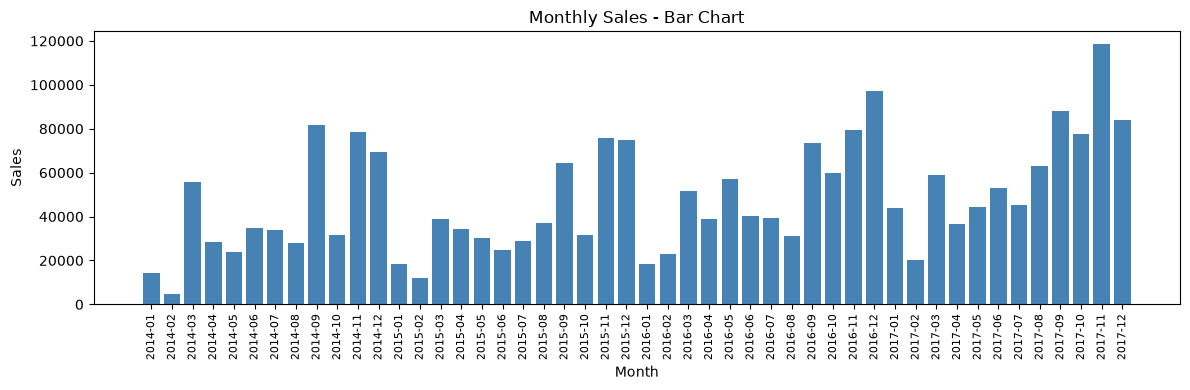

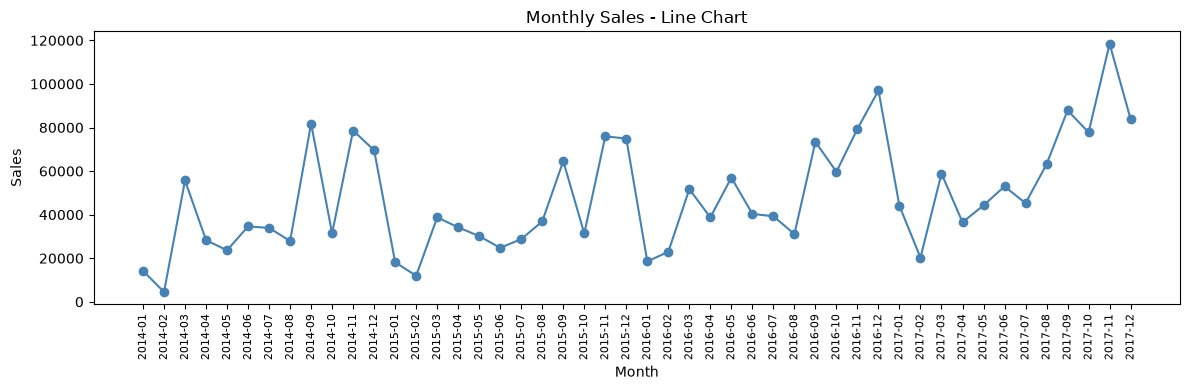

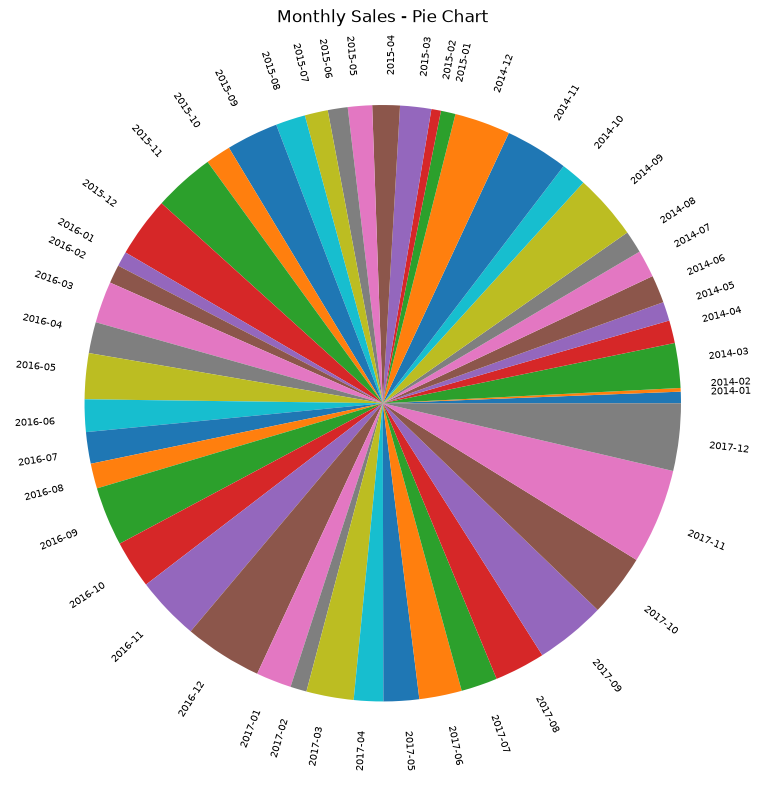

In [2]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

# 1. Bar Chart
plt.figure(figsize=(12, 4))
plt.bar(monthly_sales['YearMonth'], monthly_sales['Sales'], color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.title('Monthly Sales - Bar Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# 2. Line Chart
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.title('Monthly Sales - Line Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# 3. Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(monthly_sales['Sales'], labels=monthly_sales['YearMonth'], rotatelabels=True, textprops={'fontsize': 7})
plt.title('Monthly Sales - Pie Chart')
plt.tight_layout()
plt.show()


**Explanation:**  
The line chart shows the trend best because connecting the points in order makes it easy to see ups, downs, and seasonal patterns over time. The pie chart completely hides the trend because it has no timeline or order, and comparing slice angles is very difficult.


# Task 2: Effectiveness & Appropriateness

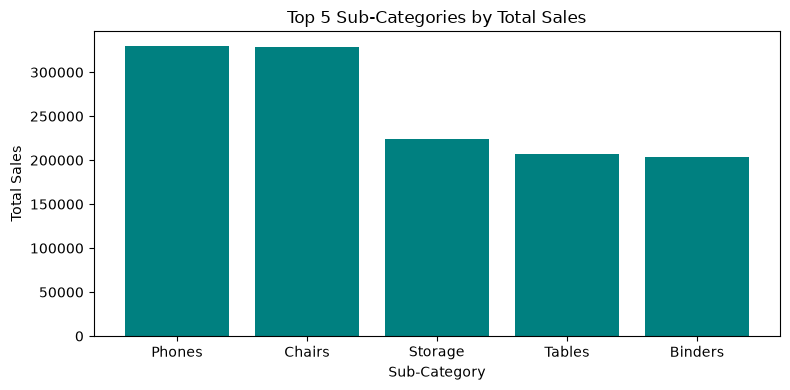

In [3]:
# 1. Compare total sales across the top 5 sub-categories
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(8, 4))
plt.bar(top5_subcat['Sub-Category'], top5_subcat['Sales'], color='teal')
plt.title('Top 5 Sub-Categories by Total Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


**Justification:**  
A bar chart works best because all bars start from a shared zero line, making it easy to compare lengths and rank the categories. A pie or radar chart performs poorly because our eyes cannot accurately judge small differences in slice angles or areas.


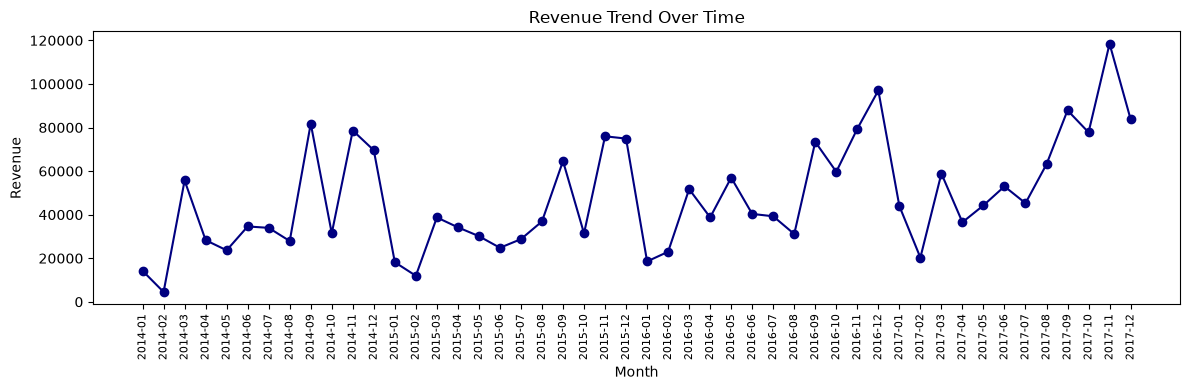

In [4]:
# 2. Show the revenue trend over time
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='navy')
plt.xticks(rotation=90, fontsize=8)
plt.title('Revenue Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


**Justification:**  
A line chart works best because it connects monthly points continuously, making the long-term direction and pattern obvious. A bar chart with 48 separate bars clutters the axis and breaks the smooth visual flow of the trend.


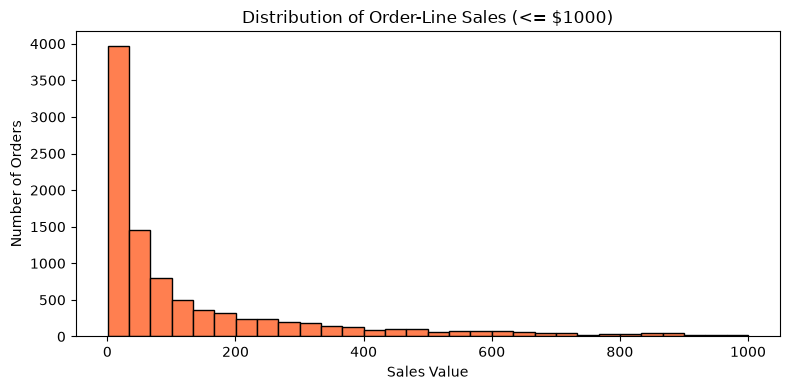

In [5]:
# 3. Show the distribution of order-line sales values
plt.figure(figsize=(8, 4))
plt.hist(df['Sales'][df['Sales'] <= 1000], bins=30, color='coral', edgecolor='black')
plt.title('Distribution of Order-Line Sales (<= $1000)')
plt.xlabel('Sales Value')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


**Justification:**  
A histogram works best because it groups orders into intervals, clearly showing that most orders are small and a few are large. A bar of averages performs poorly because a single average hides the entire range, spread, and extreme values.


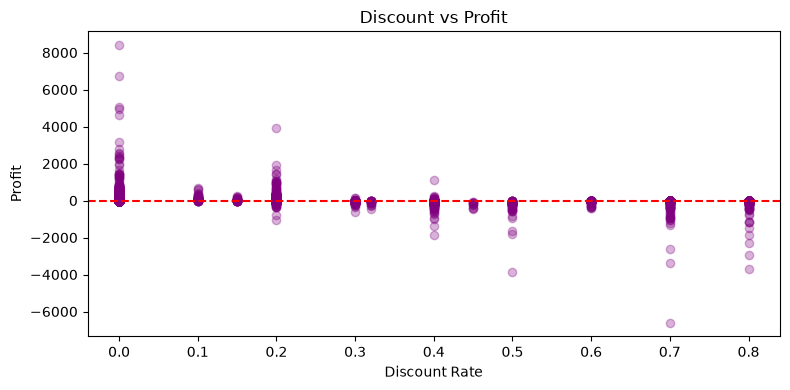

In [6]:
# 4. Show the relationship between discount level and profit
plt.figure(figsize=(8, 4))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


**Justification:**  
A scatter plot works best because it plots every individual transaction as a point, clearly showing that high discounts cause big losses. A line chart performs poorly because connecting unrelated orders creates a fake sequence that does not exist.


# Task 3: Color Selection

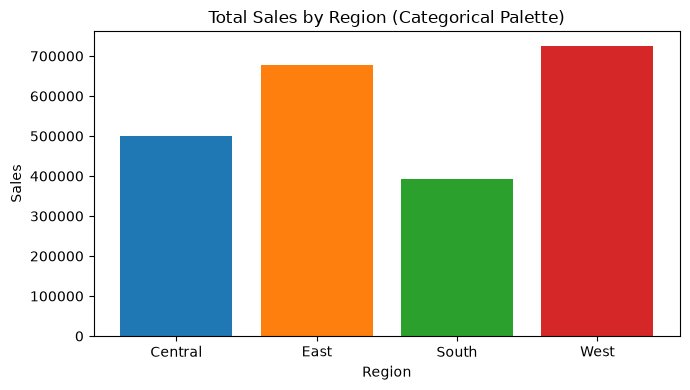

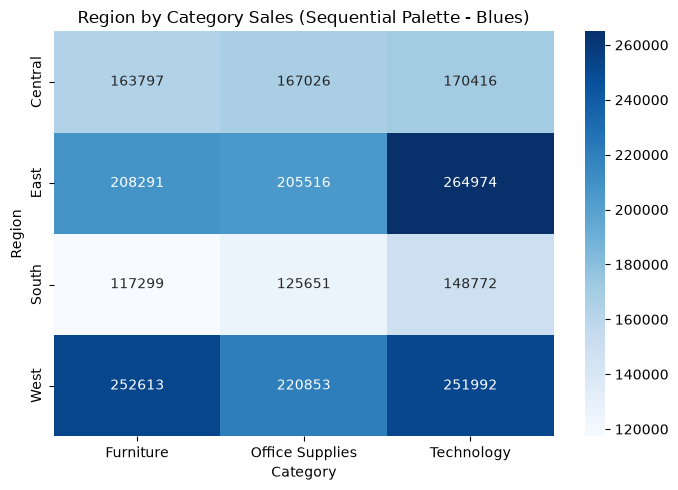

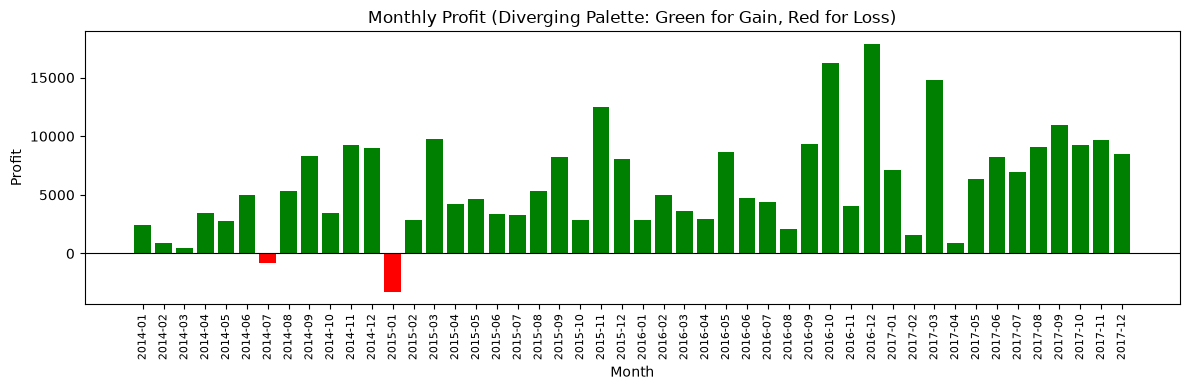

In [7]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_cat = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')
monthly_profit = df.groupby('YearMonth')['Profit'].sum().reset_index()

# (a) Categorical palette for Region Sales
plt.figure(figsize=(7, 4))
colors_cat = sns.color_palette('tab10', len(region_sales))
plt.bar(region_sales['Region'], region_sales['Sales'], color=colors_cat)
plt.title('Total Sales by Region (Categorical Palette)')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# (b) Sequential palette for Region-by-Category Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(region_cat, annot=True, fmt='.0f', cmap='Blues')
plt.title('Region by Category Sales (Sequential Palette - Blues)')
plt.tight_layout()
plt.show()

# (c) Diverging palette for Monthly Profit (crosses zero)
plt.figure(figsize=(12, 4))
profit_colors = ['green' if p >= 0 else 'red' for p in monthly_profit['Profit']]
plt.bar(monthly_profit['YearMonth'], monthly_profit['Profit'], color=profit_colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90, fontsize=8)
plt.title('Monthly Profit (Diverging Palette: Green for Gain, Red for Loss)')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


# Task 4: Accessibility

In [8]:
# (a) WCAG Contrast Ratio Function
def relative_luminance(rgb):
    linear = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in rgb]
    return 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]

def contrast_ratio(rgb1, rgb2):
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    return (max(l1, l2) + 0.05) / (min(l1, l2) + 0.05)

white = (1.0, 1.0, 1.0)
print("WCAG AA Contrast Check (Against White Background, Threshold = 4.5:1):")
for i, col in enumerate(colors_cat):
    cr = contrast_ratio(col, white)
    status = "PASS" if cr >= 4.5 else "FAIL"
    print(f"Region color {i+1}: Contrast = {cr:.2f}:1 -> {status}")


WCAG AA Contrast Check (Against White Background, Threshold = 4.5:1):
Region color 1: Contrast = 4.82:1 -> PASS
Region color 2: Contrast = 2.53:1 -> FAIL
Region color 3: Contrast = 3.40:1 -> FAIL
Region color 4: Contrast = 5.02:1 -> PASS


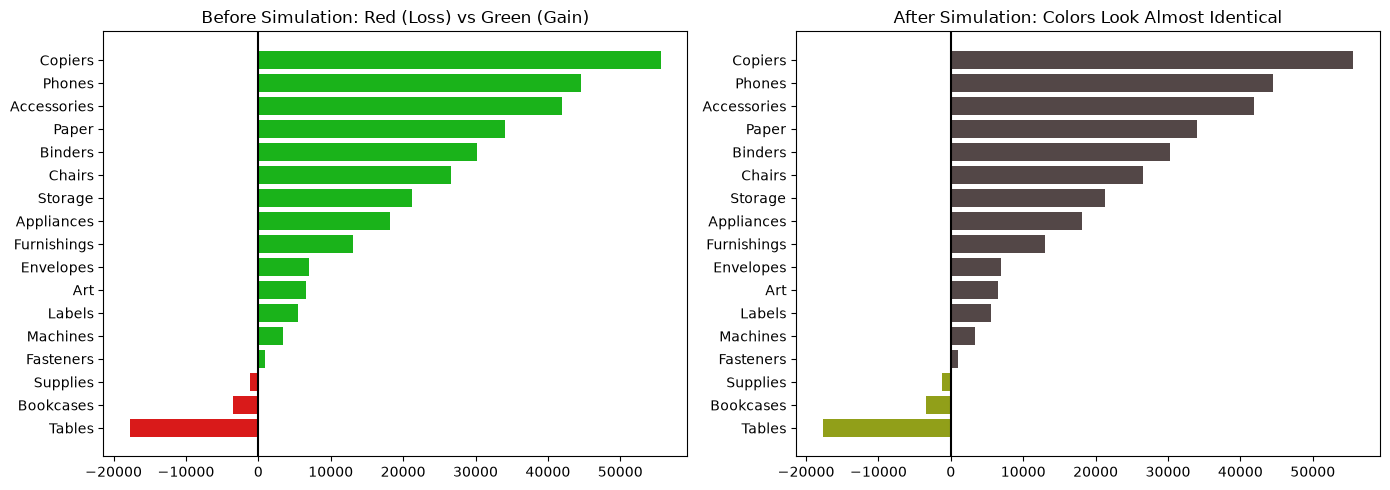

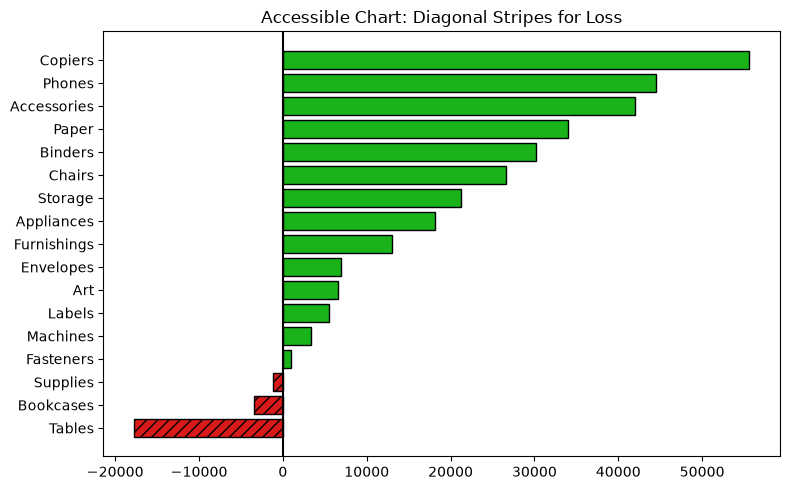

In [9]:
# (b) Profit by Sub-Category: Red/Green encoding, Simulation, and Hatching Fix
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()

# Deuteranopia simulation matrix
deuter_matrix = np.array([
    [0.625, 0.375, 0.0],
    [0.700, 0.300, 0.0],
    [0.000, 0.300, 0.700]
])

colors_orig = [(0.85, 0.1, 0.1) if p < 0 else (0.1, 0.7, 0.1) for p in subcat_profit['Profit']]
colors_sim = [np.clip(np.dot(deuter_matrix, c), 0.0, 1.0) for c in colors_orig]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors_orig)
axes[0].axvline(0, color='black')
axes[0].set_title('Before Simulation: Red (Loss) vs Green (Gain)')

axes[1].barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors_sim)
axes[1].axvline(0, color='black')
axes[1].set_title('After Simulation: Colors Look Almost Identical')
plt.tight_layout()
plt.show()

# Accessible Fix using Hatching
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors_orig, edgecolor='black')
for bar, p in zip(bars, subcat_profit['Profit']):
    if p < 0:
        bar.set_hatch('///')

ax.axvline(0, color='black')
ax.set_title('Accessible Chart: Diagonal Stripes for Loss')
plt.tight_layout()
plt.show()


**Alt Text:**  
Horizontal bar chart showing profit by sub-category, where losing sub-categories (Tables, Bookcases, Supplies) have diagonal stripe patterns, while profitable sub-categories are solid.


# Task 5: Misleading Visualizations

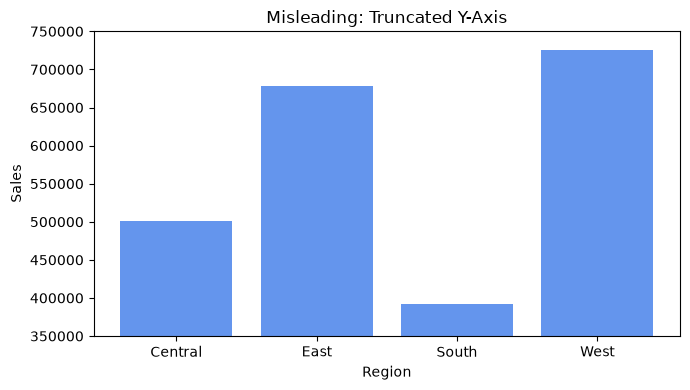

Caption: Truncated y-axis — Starting the axis at 350,000 instead of 0 makes minor differences look huge.



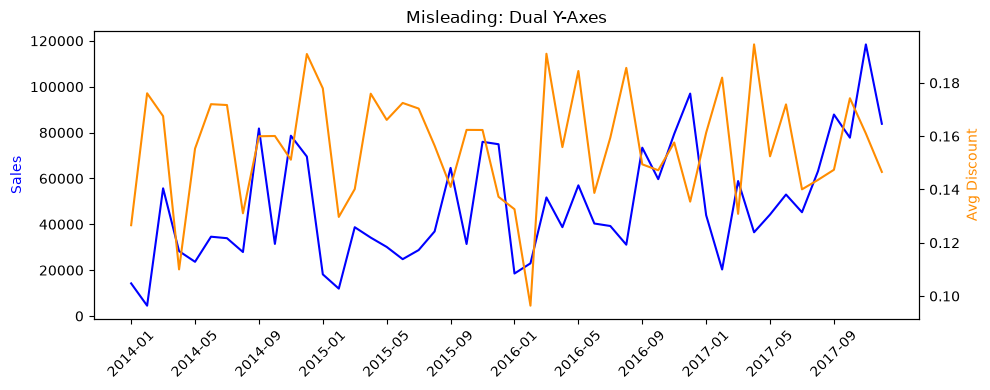

Caption: Dual y-axes — Combining two different scales creates a fake correlation between sales and discounts.



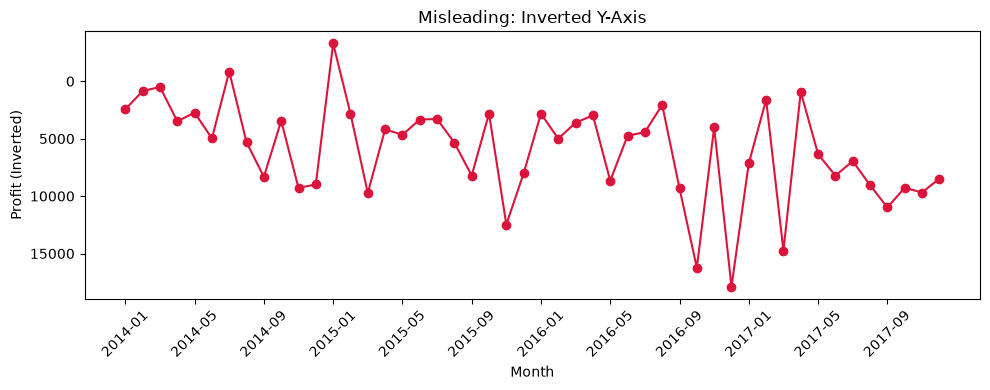

Caption: Inverted y-axis — Flipping the vertical axis makes a drop in profit look like an increase.



In [10]:
# 1. Truncated y-axis
plt.figure(figsize=(7, 4))
plt.bar(region_sales['Region'], region_sales['Sales'], color='cornflowerblue')
plt.ylim(350000, 750000)
plt.title('Misleading: Truncated Y-Axis')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()
print("Caption: Truncated y-axis — Starting the axis at 350,000 instead of 0 makes minor differences look huge.\n")

# 2. Dual-axis chart
monthly_summary = df.groupby('YearMonth').agg({'Sales': 'sum', 'Discount': 'mean'}).reset_index()
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(monthly_summary['YearMonth'], monthly_summary['Sales'], color='blue')
ax2.plot(monthly_summary['YearMonth'], monthly_summary['Discount'], color='darkorange')
ax1.set_ylabel('Sales', color='blue')
ax2.set_ylabel('Avg Discount', color='darkorange')
ax1.set_xticks(range(0, len(monthly_summary), 4))
ax1.set_xticklabels(monthly_summary['YearMonth'][::4], rotation=45)
plt.title('Misleading: Dual Y-Axes')
plt.tight_layout()
plt.show()
print("Caption: Dual y-axes — Combining two different scales creates a fake correlation between sales and discounts.\n")

# 3. Inverted y-axis
plt.figure(figsize=(10, 4))
plt.plot(monthly_profit['YearMonth'], monthly_profit['Profit'], marker='o', color='crimson')
plt.gca().invert_yaxis()
plt.xticks(range(0, len(monthly_profit), 4), monthly_profit['YearMonth'][::4], rotation=45)
plt.title('Misleading: Inverted Y-Axis')
plt.xlabel('Month')
plt.ylabel('Profit (Inverted)')
plt.tight_layout()
plt.show()
print("Caption: Inverted y-axis — Flipping the vertical axis makes a drop in profit look like an increase.\n")


# Task 6: Real Analytical Question
**Question:** *Does offering higher discounts hurt our profit?*


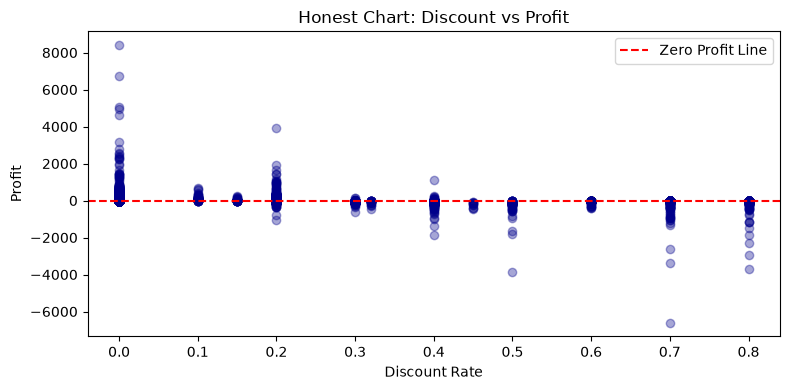

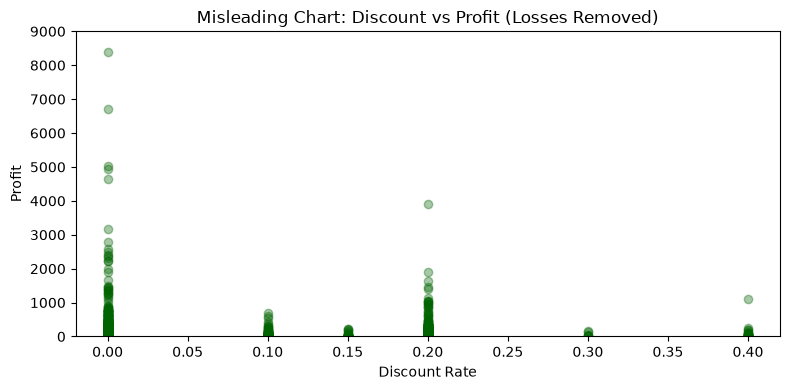

In [11]:
# 1. Honest chart
plt.figure(figsize=(8, 4))
plt.scatter(df['Discount'], df['Profit'], alpha=0.35, color='darkblue')
plt.axhline(0, color='red', linestyle='--', label='Zero Profit Line')
plt.title('Honest Chart: Discount vs Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Misleading chart (Hiding negative profits)
profitable = df[df['Profit'] > 0]
plt.figure(figsize=(8, 4))
plt.scatter(profitable['Discount'], profitable['Profit'], alpha=0.35, color='darkgreen')
plt.ylim(0, 9000)
plt.title('Misleading Chart: Discount vs Profit (Losses Removed)')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


**Justification:**  
- **Chart Type Choice:** A scatter plot shows every single order, making it clear that high discounts cause huge losses. The misleading chart hides all negative profits, dishonestly pretending discounts are always safe.
- **Color Choice:** We used neutral dark blue for dots and a clear red line at 0 profit, avoiding confusing rainbow colors.
- **Accessibility Check:** The dark blue dots and red zero line have strong contrast against the white background (above 4.5:1). Having a physical horizontal line at zero means we do not rely only on color to tell profit from loss.
